In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import joblib

In [3]:
from utils import evaluate_across_gws, select_features_by_correlation, tune_best_model

In [12]:
player_data = pd.read_csv('../rolled_data_24_25.csv', index_col=False)

avail_feats = [
 'was_home',
 'value',
 'transfers_balance',
 'selected',
 'transfers_in',
 'transfers_out',
 'difficulty',
 'opponent_difficulty',
 'win_prob',
 'percentage_net_transfers',
 'xP',
 'elo_diff',
 'ownership_change',
 'points_rolling_1',
 'points_rolling_3',
 'points_rolling_5',
 'xP_rolling_1',
 'xP_rolling_3',
 'xP_rolling_5',
 'minutes_rolling_1',
 'minutes_rolling_3',
 'minutes_rolling_5',
 'goals_scored_rolling_1',
 'goals_scored_rolling_3',
 'goals_scored_rolling_5',
 'assists_rolling_1',
 'assists_rolling_3',
 'assists_rolling_5',
 'clean_sheets_rolling_1',
 'clean_sheets_rolling_3',
 'clean_sheets_rolling_5',
 'goals_conceded_rolling_1',
 'goals_conceded_rolling_3',
 'goals_conceded_rolling_5',
 'own_goals_rolling_1',
 'own_goals_rolling_3',
 'own_goals_rolling_5',
 'yellow_cards_rolling_1',
 'yellow_cards_rolling_3',
 'yellow_cards_rolling_5',
 'saves_rolling_1',
 'saves_rolling_3',
 'saves_rolling_5',
 'influence_rolling_1',
 'influence_rolling_3',
 'influence_rolling_5',
 'creativity_rolling_1',
 'creativity_rolling_3',
 'creativity_rolling_5',
 'threat_rolling_1',
 'threat_rolling_3',
 'threat_rolling_5',
 'ict_index_rolling_1',
 'ict_index_rolling_3',
 'ict_index_rolling_5',
 'starts_rolling_1',
 'starts_rolling_3',
 'starts_rolling_5',
 'expected_goals_rolling_1',
 'expected_goals_rolling_3',
 'expected_goals_rolling_5',
 'expected_assists_rolling_1',
 'expected_assists_rolling_3',
 'expected_assists_rolling_5',
 'expected_goal_involvements_rolling_1',
 'expected_goal_involvements_rolling_3',
 'expected_goal_involvements_rolling_5',
 'expected_goals_conceded_rolling_1',
 'expected_goals_conceded_rolling_3',
 'expected_goals_conceded_rolling_5',
 'interceptions_rolling_1',
 'interceptions_rolling_3',
 'interceptions_rolling_5',
 'blocks_rolling_1',
 'blocks_rolling_3',
 'blocks_rolling_5',
 'clearances_rolling_1',
 'clearances_rolling_3',
 'clearances_rolling_5',
 'tackles_rolling_1',
 'tackles_rolling_3',
 'tackles_rolling_5',
 'chances_created_rolling_1',
 'chances_created_rolling_3',
 'chances_created_rolling_5',
 'goals_prevented_rolling_1',
 'goals_prevented_rolling_3',
 'goals_prevented_rolling_5',
 'sweeper_actions_rolling_1',
 'sweeper_actions_rolling_3',
 'sweeper_actions_rolling_5',
 'tackles_won_percent_rolling_1',
 'tackles_won_percent_rolling_3',
 'tackles_won_percent_rolling_5',
 'team_xG_rolling_1',
 'team_xG_rolling_3',
 'team_xG_rolling_5',
 'opponent_xG_rolling_1',
 'opponent_xG_rolling_3',
 'opponent_xG_rolling_5',
 'team_xGOT_rolling_1',
 'team_xGOT_rolling_3',
 'team_xGOT_rolling_5',
 'opponent_xGOT_rolling_1',
 'opponent_xGOT_rolling_3',
 'opponent_xGOT_rolling_5',
 'shots_faced_rolling_1',
 'shots_faced_rolling_3',
 'shots_faced_rolling_5',
 'opponent_shots_faced_rolling_1',
 'opponent_shots_faced_rolling_3',
 'opponent_shots_faced_rolling_5',
 'big_chances_faced_rolling_1',
 'big_chances_faced_rolling_3',
 'big_chances_faced_rolling_5',
 'opponent_big_chances_faced_rolling_1',
 'opponent_big_chances_faced_rolling_3',
 'opponent_big_chances_faced_rolling_5',
 'total_points_per_90_rolling_1',
 'total_points_per_90_rolling_3',
 'total_points_per_90_rolling_5',
 'goals_scored_per_90_rolling_1',
 'goals_scored_per_90_rolling_3',
 'goals_scored_per_90_rolling_5',
 'assists_per_90_rolling_1',
 'assists_per_90_rolling_3',
 'assists_per_90_rolling_5',
 'clean_sheets_per_90_rolling_1',
 'clean_sheets_per_90_rolling_3',
 'clean_sheets_per_90_rolling_5',
 'goals_conceded_per_90_rolling_1',
 'goals_conceded_per_90_rolling_3',
 'goals_conceded_per_90_rolling_5',
 'saves_per_90_rolling_1',
 'saves_per_90_rolling_3',
 'saves_per_90_rolling_5',
 'expected_goals_per_90_rolling_1',
 'expected_goals_per_90_rolling_3',
 'expected_goals_per_90_rolling_5',
 'expected_assists_per_90_rolling_1',
 'expected_assists_per_90_rolling_3',
 'expected_assists_per_90_rolling_5',
 'expected_goal_involvements_per_90_rolling_1',
 'expected_goal_involvements_per_90_rolling_3',
 'expected_goal_involvements_per_90_rolling_5',
 'expected_goals_conceded_per_90_rolling_1',
 'expected_goals_conceded_per_90_rolling_3',
 'expected_goals_conceded_per_90_rolling_5',
 'interceptions_per_90_rolling_1',
 'interceptions_per_90_rolling_3',
 'interceptions_per_90_rolling_5',
 'blocks_per_90_rolling_1',
 'blocks_per_90_rolling_3',
 'blocks_per_90_rolling_5',
 'clearances_per_90_rolling_1',
 'clearances_per_90_rolling_3',
 'clearances_per_90_rolling_5',
 'tackles_per_90_rolling_1',
 'tackles_per_90_rolling_3',
 'tackles_per_90_rolling_5',
 'chances_created_per_90_rolling_1',
 'chances_created_per_90_rolling_3',
 'chances_created_per_90_rolling_5',
 'goals_prevented_per_90_rolling_1',
 'goals_prevented_per_90_rolling_3',
 'goals_prevented_per_90_rolling_5',
 'sweeper_actions_per_90_rolling_1',
 'sweeper_actions_per_90_rolling_3',
 'sweeper_actions_per_90_rolling_5',
 'tackles_won_percent_per_90_rolling_1',
 'tackles_won_percent_per_90_rolling_3',
 'tackles_won_percent_per_90_rolling_5',
 'points_1_ewm',
 'points_3_ewm',
 'points_5_ewm',
 'xP_1_ewm',
 'xP_3_ewm',
 'xP_5_ewm',
 'minutes_1_ewm',
 'minutes_3_ewm',
 'minutes_5_ewm',
 'goals_scored_1_ewm',
 'goals_scored_3_ewm',
 'goals_scored_5_ewm',
 'assists_1_ewm',
 'assists_3_ewm',
 'assists_5_ewm',
 'clean_sheets_1_ewm',
 'clean_sheets_3_ewm',
 'clean_sheets_5_ewm',
 'goals_conceded_1_ewm',
 'goals_conceded_3_ewm',
 'goals_conceded_5_ewm',
 'own_goals_1_ewm',
 'own_goals_3_ewm',
 'own_goals_5_ewm',
 'yellow_cards_1_ewm',
 'yellow_cards_3_ewm',
 'yellow_cards_5_ewm',
 'saves_1_ewm',
 'saves_3_ewm',
 'saves_5_ewm',
 'influence_1_ewm',
 'influence_3_ewm',
 'influence_5_ewm',
 'creativity_1_ewm',
 'creativity_3_ewm',
 'creativity_5_ewm',
 'threat_1_ewm',
 'threat_3_ewm',
 'threat_5_ewm',
 'ict_index_1_ewm',
 'ict_index_3_ewm',
 'ict_index_5_ewm',
 'starts_1_ewm',
 'starts_3_ewm',
 'starts_5_ewm',
 'expected_goals_1_ewm',
 'expected_goals_3_ewm',
 'expected_goals_5_ewm',
 'expected_assists_1_ewm',
 'expected_assists_3_ewm',
 'expected_assists_5_ewm',
 'expected_goal_involvements_1_ewm',
 'expected_goal_involvements_3_ewm',
 'expected_goal_involvements_5_ewm',
 'expected_goals_conceded_1_ewm',
 'expected_goals_conceded_3_ewm',
 'expected_goals_conceded_5_ewm',
 'interceptions_1_ewm',
 'interceptions_3_ewm',
 'interceptions_5_ewm',
 'blocks_1_ewm',
 'blocks_3_ewm',
 'blocks_5_ewm',
 'clearances_1_ewm',
 'clearances_3_ewm',
 'clearances_5_ewm',
 'tackles_1_ewm',
 'tackles_3_ewm',
 'tackles_5_ewm',
 'chances_created_1_ewm',
 'chances_created_3_ewm',
 'chances_created_5_ewm',
 'goals_prevented_1_ewm',
 'goals_prevented_3_ewm',
 'goals_prevented_5_ewm',
 'sweeper_actions_1_ewm',
 'sweeper_actions_3_ewm',
 'sweeper_actions_5_ewm',
 'tackles_won_percent_1_ewm',
 'tackles_won_percent_3_ewm',
 'tackles_won_percent_5_ewm',
 'team_xG_1_ewm',
 'team_xG_3_ewm',
 'team_xG_5_ewm',
 'opponent_xG_1_ewm',
 'opponent_xG_3_ewm',
 'opponent_xG_5_ewm',
 'team_xGOT_1_ewm',
 'team_xGOT_3_ewm',
 'team_xGOT_5_ewm',
 'opponent_xGOT_1_ewm',
 'opponent_xGOT_3_ewm',
 'opponent_xGOT_5_ewm',
 'shots_faced_1_ewm',
 'shots_faced_3_ewm',
 'shots_faced_5_ewm',
 'opponent_shots_faced_1_ewm',
 'opponent_shots_faced_3_ewm',
 'opponent_shots_faced_5_ewm',
 'big_chances_faced_1_ewm',
 'big_chances_faced_3_ewm',
 'big_chances_faced_5_ewm',
 'opponent_big_chances_faced_1_ewm',
 'opponent_big_chances_faced_3_ewm',
 'opponent_big_chances_faced_5_ewm',
 'total_points_per_90_1_ewm',
 'total_points_per_90_3_ewm',
 'total_points_per_90_5_ewm',
 'goals_scored_per_90_1_ewm',
 'goals_scored_per_90_3_ewm',
 'goals_scored_per_90_5_ewm',
 'assists_per_90_1_ewm',
 'assists_per_90_3_ewm',
 'assists_per_90_5_ewm',
 'clean_sheets_per_90_1_ewm',
 'clean_sheets_per_90_3_ewm',
 'clean_sheets_per_90_5_ewm',
 'goals_conceded_per_90_1_ewm',
 'goals_conceded_per_90_3_ewm',
 'goals_conceded_per_90_5_ewm',
 'saves_per_90_1_ewm',
 'saves_per_90_3_ewm',
 'saves_per_90_5_ewm',
 'expected_goals_per_90_1_ewm',
 'expected_goals_per_90_3_ewm',
 'expected_goals_per_90_5_ewm',
 'expected_assists_per_90_1_ewm',
 'expected_assists_per_90_3_ewm',
 'expected_assists_per_90_5_ewm',
 'expected_goal_involvements_per_90_1_ewm',
 'expected_goal_involvements_per_90_3_ewm',
 'expected_goal_involvements_per_90_5_ewm',
 'expected_goals_conceded_per_90_1_ewm',
 'expected_goals_conceded_per_90_3_ewm',
 'expected_goals_conceded_per_90_5_ewm',
 'interceptions_per_90_1_ewm',
 'interceptions_per_90_3_ewm',
 'interceptions_per_90_5_ewm',
 'blocks_per_90_1_ewm',
 'blocks_per_90_3_ewm',
 'blocks_per_90_5_ewm',
 'clearances_per_90_1_ewm',
 'clearances_per_90_3_ewm',
 'clearances_per_90_5_ewm',
 'tackles_per_90_1_ewm',
 'tackles_per_90_3_ewm',
 'tackles_per_90_5_ewm',
 'chances_created_per_90_1_ewm',
 'chances_created_per_90_3_ewm',
 'chances_created_per_90_5_ewm',
 'goals_prevented_per_90_1_ewm',
 'goals_prevented_per_90_3_ewm',
 'goals_prevented_per_90_5_ewm',
 'sweeper_actions_per_90_1_ewm',
 'sweeper_actions_per_90_3_ewm',
 'sweeper_actions_per_90_5_ewm',
 'tackles_won_percent_per_90_1_ewm',
 'tackles_won_percent_per_90_3_ewm',
 'tackles_won_percent_per_90_5_ewm'
]

data = player_data[player_data['position'] == 'Defender']

## Select Feats


In [15]:
feats = {}
for round in range(6, 39):
    curr = data[(data['round'] > 3) & (data['round'] < round)].fillna(0)
    feats_selected = select_features_by_correlation(curr, avail_feats, min_corr=0.1, redundancy_threshold = 0.5)

    feats[round] = feats_selected

feats

  dropping 'points_rolling_3' (|corr| with xP=0.884) -- |corr|=0.884 with already-selected 'xP'
  dropping 'points_3_ewm' (|corr| with xP=0.868) -- |corr|=0.868 with already-selected 'xP'
  dropping 'points_5_ewm' (|corr| with xP=0.866) -- |corr|=0.866 with already-selected 'xP'
  dropping 'xP_1_ewm' (|corr| with xP=0.864) -- |corr|=0.864 with already-selected 'xP'
  dropping 'xP_rolling_1' (|corr| with xP=0.864) -- |corr|=0.864 with already-selected 'xP'
  dropping 'xP_3_ewm' (|corr| with xP=0.845) -- |corr|=0.845 with already-selected 'xP'
  dropping 'xP_rolling_3' (|corr| with xP=0.816) -- |corr|=0.816 with already-selected 'xP'
  dropping 'xP_5_ewm' (|corr| with xP=0.811) -- |corr|=0.811 with already-selected 'xP'
  dropping 'clean_sheets_rolling_3' (|corr| with xP=0.774) -- |corr|=0.774 with already-selected 'xP'
  dropping 'clean_sheets_per_90_rolling_3' (|corr| with xP=0.762) -- |corr|=0.762 with already-selected 'xP'
  dropping 'clean_sheets_5_ewm' (|corr| with xP=0.758) -- |co

{6: ['transfers_out',
  'opponent_difficulty',
  'xP',
  'elo_diff',
  'ownership_change',
  'clean_sheets_rolling_1',
  'expected_assists_rolling_3',
  'expected_goals_conceded_rolling_3',
  'tackles_won_percent_rolling_1',
  'opponent_shots_faced_rolling_3',
  'blocks_per_90_rolling_3',
  'tackles_per_90_rolling_3',
  'chances_created_per_90_rolling_1',
  'assists_3_ewm',
  'yellow_cards_3_ewm',
  'expected_goals_5_ewm',
  'interceptions_1_ewm',
  'team_xG_5_ewm',
  'total_points_per_90_1_ewm',
  'total_points_per_90_5_ewm',
  'goals_scored_per_90_5_ewm',
  'clearances_per_90_5_ewm'],
 7: ['transfers_out',
  'difficulty',
  'xP',
  'elo_diff',
  'ownership_change',
  'points_rolling_5',
  'assists_rolling_5',
  'clean_sheets_rolling_1',
  'yellow_cards_rolling_3',
  'expected_goals_conceded_rolling_3',
  'interceptions_rolling_1',
  'tackles_won_percent_rolling_1',
  'opponent_xGOT_rolling_3',
  'total_points_per_90_rolling_3',
  'expected_goals_per_90_rolling_5',
  'expected_goal_in

In [16]:
joblib.dump(feats, './hist/feats_def')

['./hist/feats_def']

## Models


In [ ]:
models_by_round = {}
mae_by_round = {}
r2_by_round = {}
tuned_models = []

for round in range(5, 38):
    # Multi-gameweek comparison (more robust signal, recommended)
    print(f"\n=== Averaged across rounds {3}-{round} ===")

    feats_round = feats[round+1]
    # print(feats_round)
    feats_round = feats_round + ['round', 'element','was_home']

    # Step 1: compare models across several rounds
    combined, summary = evaluate_across_gws(data[feats_round], gw_list=range(3,round+1))
    print(summary.to_string(index=False))

    base_name = summary.sort_values("MAE").iloc[0]["model"]
    base_mae = summary.sort_values("MAE").iloc[0]["MAE"]
    base_r2 = summary.sort_values("MAE").iloc[0]["R2"]


    # Step 2: tune the winner, validating on rounds 6-round, holding out round+1
    best_model, best_estimator, search, c_final, mae, rmse, r2 = tune_best_model(
        data[feats_round],
        summary,
        val_gws=range(1,round),
        final_test_gw=round+1,
        n_iter=40,
    )

    if mae > base_mae:
        # mae_by_round[round+1] = mae
        models_by_round[round+1] = {
            'mae': mae,
            'r2': r2,
            "best_model": best_model,
            "c_final": c_final,
            "best_estimator": best_estimator,
            "search": search
        }
    else:
        # mae_by_round[round+1] = base_mae
        models_by_round[round+1] = {
            'mae': base_mae,
            'r2': base_r2,
            "best_model": base_name,
            "c_final": c_final
        }



=== Averaged across rounds 3-5 ===
               model      MAE     RMSE       R2
        RandomForest 0.559429 0.843017 0.723511
HistGradientBoosting 0.594547 0.870219 0.709371
            LightGBM 0.612559 0.894224 0.693553
             XGBoost 0.618282 0.924215 0.669438
Best model from comparison: RandomForest
Fitting 3 folds for each of 40 candidates, totalling 120 fits

Best CV MAE: 0.880
Best params:
  regressor__max_depth: 10
  regressor__max_features: sqrt
  regressor__min_samples_leaf: 2
  regressor__min_samples_split: 3
  regressor__n_estimators: 319

Holdout (round 6) performance:
  MAE=0.500  RMSE=0.800  R2=0.742

=== Averaged across rounds 3-6 ===
               model      MAE     RMSE       R2
        RandomForest 0.575872 0.882621 0.693565
HistGradientBoosting 0.594988 0.882913 0.694675
             XGBoost 0.611933 0.939537 0.654019
            LightGBM 0.613584 0.924134 0.665113
Best model from comparison: RandomForest
Fitting 4 folds for each of 40 candidates, total

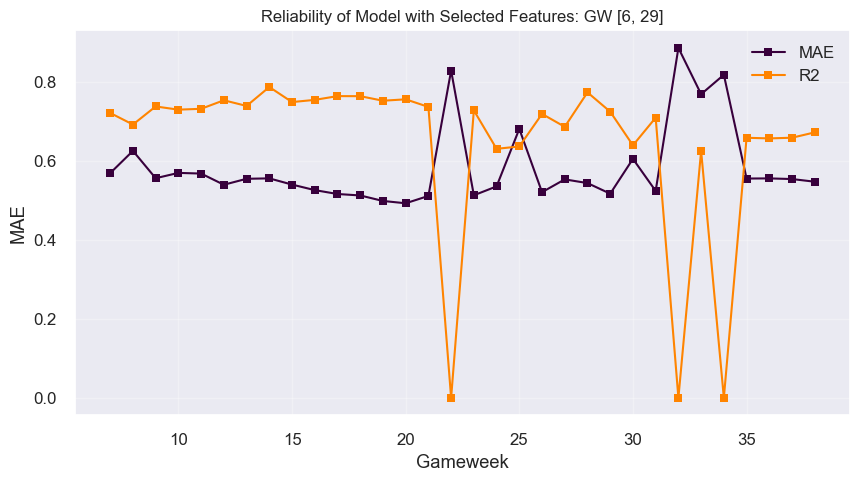

In [ ]:
# --- Visualization ---
plt.figure(figsize=(10, 5))
plt.plot(mae_by_round.keys(), mae_by_round.values(), marker='s', color="#38003c", label='MAE')

plt.plot(r2_by_round.keys(), r2_by_round.values(), marker='s', color="#ff8400", label='R2')
plt.title('Reliability of Model with Selected Features: GW [6, 29]', fontsize=12)
plt.xlabel('Gameweek')
plt.ylabel('MAE')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [ ]:
joblib.dump(models_by_round, './models_by_round_def')

['./models_by_round_gk']